In [52]:
df = pd.read_csv("data_annonces.csv")

In [53]:
df.shape

(2897, 34)

<Axes: xlabel='prix_m2', ylabel='Count'>

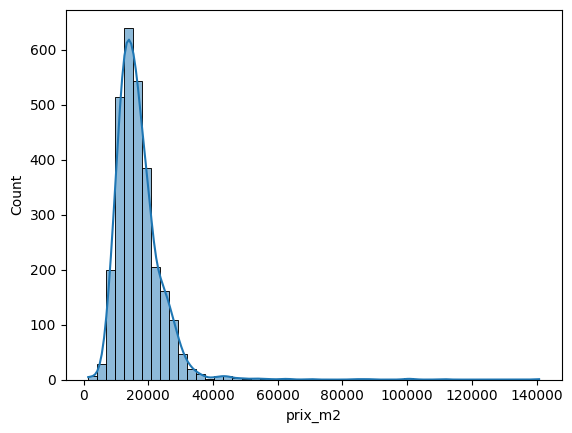

In [25]:
# distribution du prix m2 avec seaborn
import seaborn as sns
sns.histplot(df['prix_m2'], bins=50, kde=True)

<Axes: xlabel='log_prix_m2', ylabel='Count'>

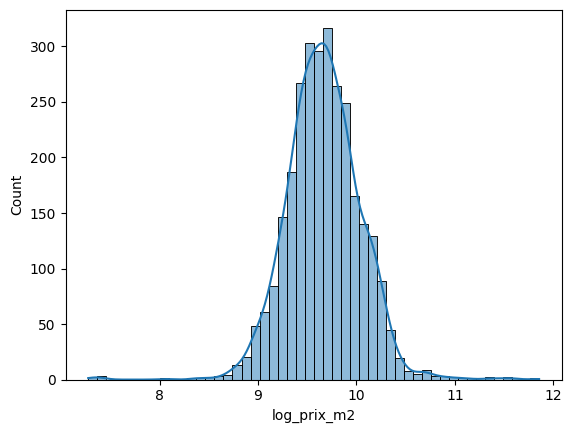

In [26]:
# distribution du log prix m2 avec seaborn
import seaborn as sns
sns.histplot(df1['log_prix_m2'], bins=50, kde=True)

<Axes: xlabel='surface_m2', ylabel='Count'>

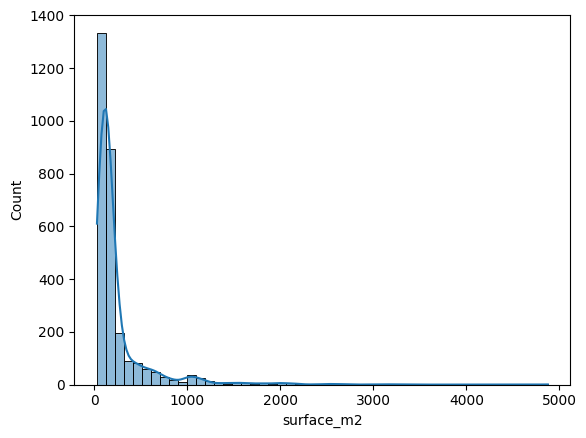

In [27]:
# distribution de surface avec seaborn
sns.histplot(df['surface_m2'], bins=50, kde=True)

<Axes: xlabel='log_surface_m2', ylabel='Count'>

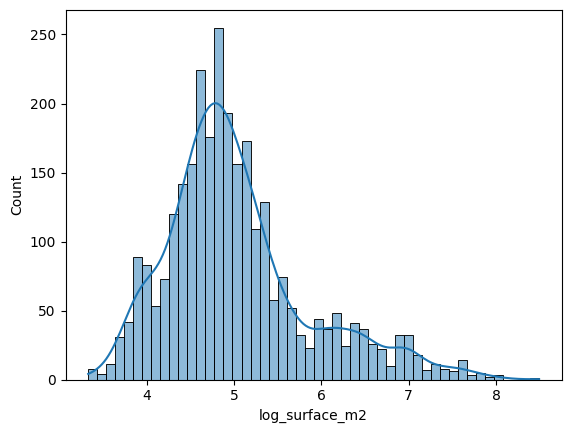

In [28]:
# distribution de log surface avec seaborn
sns.histplot(df['log_surface_m2'], bins=50, kde=True)

In [29]:
# filtrer les quartiers avec moins de 10 observations
quartier_counts = df['quartier'].value_counts()
quartiers_to_keep = quartier_counts[quartier_counts >= 10].index
df = df[df['quartier'].isin(quartiers_to_keep)]

In [30]:
len(df['quartier'].value_counts())

50

In [31]:
# supprimer les doublons
len_avant = len(df)
df = df.drop_duplicates(subset=[c for c in df.columns if c not in ['log_prix_m2', 'log_surface_m2']])
print(f"Doublons supprimés : {len_avant - len(df)}")
print("Shape après déduplication :", df.shape)

Doublons supprimés : 93
Shape après déduplication : (2804, 34)


C:\Users\del\AppData\Local\Temp\ipykernel_20168\4105747275.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  vars_cat = df.select_dtypes(include='object').columns


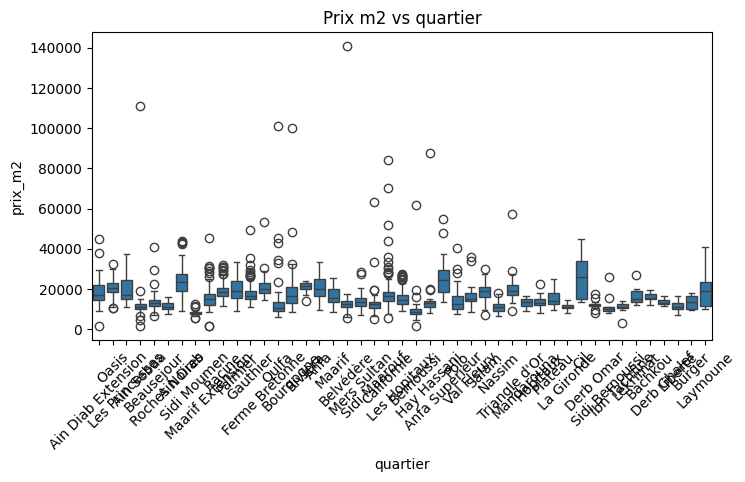

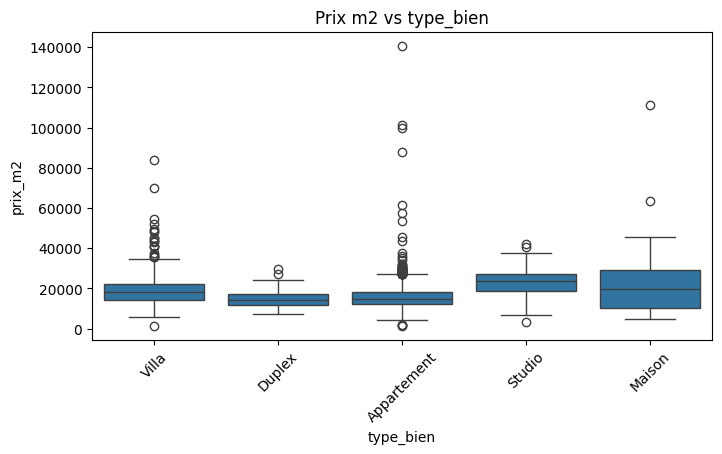

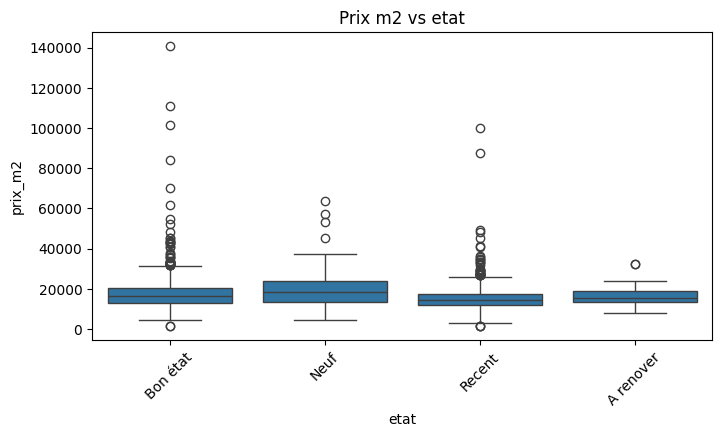

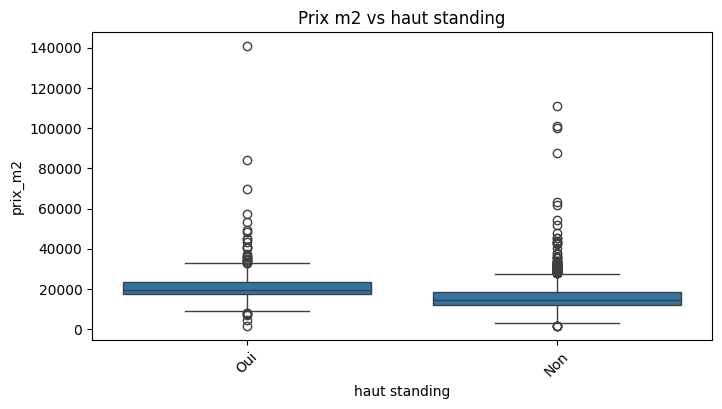

In [54]:
import matplotlib.pyplot as plt
vars_cat = df.select_dtypes(include='object').columns
# prix vs vars_cat
for col in vars_cat:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=col, y='prix_m2', data=df)
    plt.title(f'Prix m2 vs {col}')
    plt.xticks(rotation=45)
    plt.show()

In [62]:
df.columns

Index(['quartier', 'type_bien', 'prix_m2', 'etat', 'surface_m2', 'latitude',
       'longitude', 'dist_tram_m', 'tram_500m', 'intersect_500m',
       'tt_centre_min', 'tt_cfc_min', 'tt_maarif_min', 'tt_sidi_maarouf_min',
       'tt_port_min', 'n_ecoles_500m', 'n_ecoles_1km', 'dist_ecole_m',
       'n_banques_500m', 'n_banques_1km', 'dist_banque_m', 'n_malls_500m',
       'n_malls_1km', 'dist_mall_m', 'dist_mer_m', 'dist_parc_m',
       'n_parcs_1km', 'surface_verte_m2_1km', 'nuisance_route_500m',
       'n_industries_500m', 'n_fuel_500m', 'haut standing', 'log_prix_m2',
       'log_surface_m2'],
      dtype='str')

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error, make_scorer

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 1. Préparation et copie des données
# On nettoie les noms de colonnes et on gère les valeurs manquantes avant toute transformation.
df_encoded.columns = df_encoded.columns.str.strip()
df_encoded = df.copy()
df_encoded.columns = df_encoded.columns.str.strip()
df_encoded['etat'] = df_encoded['etat'].fillna('Bon état')

cible = 'log_prix_m2'
X = df_encoded.drop(columns=[cible, 'prix_m2', 'surface_m2','latitude', 'longitude'])
y = df_encoded[cible]

vars_cat = X.select_dtypes(include=['object', 'category']).columns.tolist()
vars_num = X.select_dtypes(include='number').columns.tolist()

cat_idx = [X.columns.get_loc(c) for c in vars_cat]

# 2. Préprocesseurs
# OHE uniquement pour la régression linéaire
preprocessor_linear = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), vars_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), vars_cat)
    ]
)

# Ordinal encoding pour les modèles basés sur des arbres
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), vars_num),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), vars_cat)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Régression linéaire': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror'),
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1)
}

scoring = {
    'r2': 'r2',
    'neg_mape': make_scorer(mean_absolute_percentage_error, greater_is_better=False)
}

scores = []
for name, model in models.items():
    preprocessor = preprocessor_linear if name == 'Régression linéaire' else preprocessor_tree
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)

    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
    test_mape = mean_absolute_percentage_error(y_test, y_test_pred)

    cv = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1, return_train_score=False)
    cv_r2 = cv['test_r2'].mean()
    cv_r2_std = cv['test_r2'].std()
    cv_mape = -cv['test_neg_mape'].mean()
    cv_mape_std = -cv['test_neg_mape'].std()

    scores.append({
        'Modèle': name,
        'CV R2': cv_r2,
        'CV R2 (std)': cv_r2_std,
        'CV MAPE ': cv_mape*100,
        'CV MAPE (std)': cv_mape_std*100,
        'Test R2': test_r2,
        'Test MAPE': test_mape*100

    })

results = pd.DataFrame(scores)
results

C:\Users\del\AppData\Local\Temp\ipykernel_20168\3796379371.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  vars_cat = X.select_dtypes(include=['object', 'category']).columns.tolist()


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004647 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3626
[LightGBM] [Info] Number of data points in the train set: 2243, number of used features: 29
[LightGBM] [Info] Start training from score 9.663484


c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Modèle,CV R2,CV R2 (std),CV MAPE,CV MAPE (std),Test R2,Test MAPE
0,Régression linéaire,0.467835,0.047859,1.899840,-0.146008,0.491473,1.865337
1,Decision Tree,-0.049418,0.149214,2.630921,-0.131790,-0.056659,2.659657
2,Random Forest,0.400299,0.045767,1.999903,-0.146206,0.426127,1.950647
3,XGBoost,0.400709,0.041865,1.996029,-0.137659,0.464699,1.875863
4,LightGBM,0.455447,0.051271,1.902307,-0.139210,0.513687,1.798248


In [17]:
df.columns = df_encoded.columns.str.strip()

In [64]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

# recherche d'hyperparamètres
param_grids = {
    'Ridge': {
        'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    'Lasso': {
        'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
    },
    'Decision Tree': {
        'model__max_depth': [3, 5, 8, 12, 15],
        'model__min_samples_split': [2, 4, 6, 10],
        'model__min_samples_leaf': [1, 2, 3, 4]
    },
    'Random Forest': {
        'model__n_estimators': [50, 100, 150, 200],
        'model__max_depth': [None, 8, 12, 16],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'model__n_estimators': [50, 100, 150, 200],
        'model__max_depth': [3, 5, 7, 10],
        'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'model__subsample': [0.6, 0.8, 1.0],
        'model__colsample_bytree': [0.6, 0.8, 1.0]
    },
    'LightGBM': {
        'model__n_estimators': [50, 100, 150, 200],
        'model__num_leaves': [15, 31, 50],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__min_child_samples': [5, 10, 20]
    }
}

tuning_models = {
    'Ridge': Ridge(max_iter=10000),
    'Lasso': Lasso(max_iter=10000),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror'),
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1)
}

vars_cat = X.select_dtypes(include=['object', 'category']).columns.tolist()
vars_num = X.select_dtypes(include='number').columns.tolist()

preprocessor_linear = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), vars_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), vars_cat)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), vars_num),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), vars_cat)
    ]
)

hyper_results = []
for name, model in tuning_models.items():
    preprocessor = preprocessor_linear if name in ['Ridge', 'Lasso'] else preprocessor_tree
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    params = param_grids[name]

    if name in ['Ridge', 'Lasso']:
        search = GridSearchCV(pipe, params, cv=5, scoring='r2', n_jobs=-1)
    else:
        search = RandomizedSearchCV(pipe, params, n_iter=20, cv=5, scoring='r2', n_jobs=-1, random_state=42)

    search.fit(X_train, y_train)
    best = search.best_estimator_
    best_params = search.best_params_

    cv = cross_validate(best, X, y, cv=5, scoring=scoring, n_jobs=-1, return_train_score=False)
    hyper_results.append({
        'Modèle': name,
        'Best params': best_params,
        'CV R2 ': cv['test_r2'].mean(),
        'CV R2 (std)': cv['test_r2'].std(),
        'CV MAPE ': -cv['test_neg_mape'].mean()*100,
        'CV MAPE (std)': -cv['test_neg_mape'].std()*100
    })

hyper_df = pd.DataFrame(hyper_results)
hyper_df

C:\Users\del\AppData\Local\Temp\ipykernel_18752\1727792772.py:49: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  vars_cat = X.select_dtypes(include=['object', 'category']).columns.tolist()


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000827 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3629
[LightGBM] [Info] Number of data points in the train set: 2317, number of used features: 29
[LightGBM] [Info] Start training from score 9.669430


,Modèle,Best params,CV R2,CV R2 (std),CV MAPE,CV MAPE (std)
0,Ridge,{'model__alpha': 1},0.470841,0.044897,1.875815,-0.135289
1,Lasso,{'model__alpha': 0.0001},0.472329,0.047308,1.876246,-0.137481
2,Decision Tree,"{'model__min_samples_split': 4, 'model__min_sa...",0.247138,0.178155,2.215991,-0.215493
3,Random Forest,"{'model__n_estimators': 200, 'model__min_sampl...",0.429014,0.049534,1.913093,-0.111002
4,XGBoost,"{'model__subsample': 0.8, 'model__n_estimators...",0.471078,0.038813,1.837726,-0.138695
5,LightGBM,"{'model__num_leaves': 15, 'model__n_estimators...",0.467365,0.029711,1.860543,-0.125419
